# Trigonal tellurium: spin accumulation coefficient (SAC)

The spin accumulation coefficient (SAC, Shitade & Minamitani, *npj Spintronics*
**3**, 29 (2025), "SM25") characterizes the spin accumulated at a surface by the
spin Hall effect, evaluated as a **bulk** Fermi-surface property
(`analysis.spin_accumulation` — a genuinely new capability, no released
Wannier90/postw90 implementation exists to compare against).  This notebook
reproduces SM25's own trigonal-tellurium example (their Fig. 2): the SAC
$\gamma^{ij}_{sa}$ decomposed by the $D_3$ point group into 4 independent
channels $\gamma_{1..4}$, alongside the conventional spin Hall conductivity
$\sigma_\alpha$ (same decomposition, Qiao method, postw90-certified machinery).

**Structure**: space group $P3_121$ (No. 152, $D_3^4$), $a=4.457\,$Å,
$c=5.9581\,$Å, Te at Wyckoff $3a$, $x=0.274036$.

Two choices control the result:

1. **The Wannier model.**  A (6,6,8) mesh with **24 spinor WFs** (s+p per Te):
   the 18 valence bands (s + p-valence, incl. the H-point valence/conduction
   touching) are **frozen exactly**, and 6 p-conduction bands are disentangled
   from above.  Valence-only models give a perfect SAC but a spurious *zero*
   in-gap SHC (no virtual conduction states); p-only models damage the valence
   top and break the $D_3$/$C_3$ consistency by O(1).
2. **The formula.**  Three kernel-level corrections, each pinned by an exact
   anchor (`tests/test_spin_accumulation.py`): (i) $s^i_{na}$ needs the
   ab-initio `.sIu` matrix elements *and* the Berry connection *and* the
   in-subspace interband $S\!\cdot\!D$ term (a first correction dropped the
   latter — caught by a tight-binding-limit test where SM25 Eq. 1 has an exact
   closed form; the fixed kernel matches it to $10^{-14}$); (ii) the orbital
   moment convention of postw90 is exactly $-2\times$ SM25's Eq. 2c $m$;
   (iii) the $-(e/\hbar)$ prefactor applies literally with $e=+|e|$ (settled
   by the Fig. 2 anchors below).  The article's **HTML MathML** (in `pdf/`)
   validates every equation, and Fig. 2 fixes the unit: $\gamma$ in
   $(\hbar/e)$ S/cm, same conversion as $\sigma$.

In [1]:
import os, sys, pathlib
import numpy as np
import matplotlib.pyplot as plt
import torch

HERE = pathlib.Path.cwd()
REPO = HERE
while not (REPO / 'waw').exists() and REPO != REPO.parent:
    REPO = REPO.parent
sys.path.insert(0, str(REPO))

import waw
waw.set_num_threads(16)
from ase import Atoms
from waw.interfaces import quantum_espresso as qe
from waw.interfaces.ase.structure import real_lattice, recip_lattice, monkhorst_pack
from waw.interfaces.quantum_espresso.io import read_bands_eigenvalues
from waw.core.pipeline import load_wannier_result
from waw.analysis.elph import band_eigensystem
import waw.analysis.spin_hall  # registers the 'spin_hall_conductivity' SI converter
from waw.vis.windows import plot_wannierization_windows
from waw.units import EV_TO_HARTREE, HARTREE_TO_EV, BOHR_TO_ANG, to_si_units

W = REPO / 'workflows' / 'notebooks' / 'runs' / 'te_sac_dense'

a_lat, c_lat = 4.457, 5.9581176
cell = [[a_lat, 0, 0], [-a_lat / 2, a_lat * np.sqrt(3) / 2, 0], [0, 0, c_lat]]
frac = [[0.274036, 0.274036, 0.0], [-0.274036, 0.0, 1 / 3], [0.0, -0.274036, 2 / 3]]
atoms = Atoms('Te3', scaled_positions=frac, cell=cell, pbc=True)
MP_GRID = (6, 6, 8)
rl = real_lattice(atoms); rc = recip_lattice(atoms)
V_CELL = abs(np.linalg.det(rl))

# the model and every operator were produced by the cached pipeline run
# (scratch te_post.py; QE data + caches live in runs/te_sac_dense):
#   overlaps: ecutwfc=40, nbnd=58, exclude_bands 1-30 (Te-4d semicore),
#             SOC, spn+uHu+sIu, 24 s;p projections (atom-local x axes)
#   wannierize: nw=24, outer (-5.0, 16.5) eV, frozen (-5.0, 9.3) eV,
#             cg, n_restarts=3, dis_n_iter=5000, n_iter=10000, tol 1e-10
res = load_wannier_result(W / 'te24_result.npz')
ops = np.load(W / 'te24_operators.npz')
E_FERMI = float(ops['EF'])
print(f"Omega_I = {float(ops['omega_i']) * BOHR_TO_ANG**2:.4f} Ang^2   "
      f"Omega = {float(ops['omega']) * BOHR_TO_ANG**2:.4f} Ang^2   "
      f"E_F = {E_FERMI:.4f} eV")

Omega_I = 35.9166 Ang^2   Omega = 43.2519 Ang^2   E_F = 8.9861 eV


### 1. The model, with its windows where they act

Bands below 2 eV are the Te-5s manifold; the 18 s+p-valence bands top out at
$E_F+0.94$ eV where the famous H-point valence/conduction **touching** sits —
no frozen window can separate touching bands, so with `nw=24` the frozen top
(9.3 eV = $E_F+0.31$... note: *absolute* 9.3 eV) simply swallows both partners
(18–20 frozen bands per k-point $\le$ 24, all exact), and disentanglement only
has to choose the 6 p-conduction WFs from the outer window.

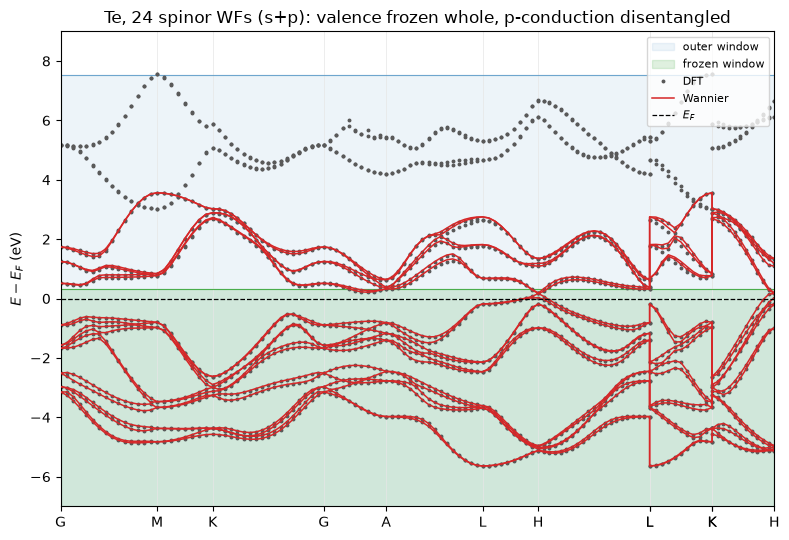

model band edges: VBM-EF = +0.093 eV, CBM-EF = +0.171 eV (QE fine mesh: +0.027 / +0.171)


In [2]:
bp = np.load(W / 'band_path.npz')
hr = res.hr
wann = band_eigensystem(hr, bp['kpts'])[0] * HARTREE_TO_EV
dft = read_bands_eigenvalues(W / 'te.bands.out', nbnd=58)[:, 30:]  # semicore excluded

fig, ax = plt.subplots(figsize=(8, 5.5))
plot_wannierization_windows(ax, bp['x'], dft, wann,
                            outer_window=(-5.0, 16.5), frozen_window=(-5.0, 9.3),
                            fermi_energy=E_FERMI, xticks=bp['xticks'],
                            xticklabels=list(bp['labels']), ylim=(-7, 9))
ax.set_ylabel(r'$E - E_F$ (eV)')
ax.set_title('Te, 24 spinor WFs (s+p): valence frozen whole, p-conduction disentangled')
plt.tight_layout(); plt.show()

eig_chk, _ = band_eigensystem(hr, monkhorst_pack((24, 24, 32)))
EFh = E_FERMI * EV_TO_HARTREE
vbm = float(eig_chk[eig_chk < EFh + 0.15 * EV_TO_HARTREE].max()) / EV_TO_HARTREE
cbm = float(eig_chk[eig_chk > EFh + 0.15 * EV_TO_HARTREE].min()) / EV_TO_HARTREE
print(f'model band edges: VBM-EF = {vbm - E_FERMI:+.3f} eV, CBM-EF = {cbm - E_FERMI:+.3f} eV '
      f'(QE fine mesh: +0.027 / +0.171)')

### 2. The 4 $D_3$ invariant tensors, from first principles — and validated
against the article's own MathML

SM25's printed Eq. 8 lists the nonzero components of $\epsilon^{ij}_{\alpha a}$
as a chain of "=" signs whose minus signs are invisible in the typeset PDF.
Rather than trust the transcription, the 4 tensors are derived here directly:
build the $D_3$ point group (6 proper rotations) and project the full rank-3
$(i,j,a)$ tensor space onto its invariant subspace.  Exactly 4 invariant
directions survive, with $n_\alpha = (2,4,2,2)$ nonzero components — and the
**article's HTML** (whose MathML preserves every sign) confirms all four
channels *exactly*:

$$\epsilon_1^{xy,z}=-\epsilon_1^{yx,z}=1,\quad
  \epsilon_2^{xx,x}=-\epsilon_2^{yy,x}=-\epsilon_2^{xy,y}=-\epsilon_2^{yx,y}=1,$$
$$\epsilon_3^{yz,x}=-\epsilon_3^{xz,y}=1,\quad
  \epsilon_4^{zx,y}=-\epsilon_4^{zy,x}=1.$$

The missing PDF minus signs were a rendering artifact; the paper and the group
theory agree.

In [3]:
def _Rz(theta):
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s, 0], [s, c, 0], [0, 0, 1]])

def _d3_group():
    C3, C2x = _Rz(2 * np.pi / 3), np.diag([1.0, -1.0, -1.0])
    group, changed = [np.eye(3)], True
    while changed:
        changed = False
        for g in list(group):
            for h in (C3, C2x):
                gh = g @ h
                if not any(np.allclose(gh, x, atol=1e-12) for x in group):
                    group.append(gh); changed = True
    return group

group = _d3_group()
assert len(group) == 6

P = np.zeros((27, 27))
for R in group:
    P += np.einsum('ip,jq,ar->ijapqr', R, R, R).reshape(27, 27)
P /= len(group)
vals, vecs = np.linalg.eigh(P)
inv = vecs[:, vals > 0.99].T
assert inv.shape[0] == 4

# rotate the invariant basis onto SM25's channels (defined by which
# components are nonzero) and normalize the leading entry to +1
idx = {'x': 0, 'y': 1, 'z': 2}
def _mk(comps):
    T = np.zeros((3, 3, 3))
    for i, j, aa, val in comps:
        T[idx[i], idx[j], idx[aa]] = val
    return T
EPS = [_mk([('x', 'y', 'z', 1.), ('y', 'x', 'z', -1.)]),
       _mk([('x', 'x', 'x', 1.), ('y', 'y', 'x', -1.), ('x', 'y', 'y', -1.), ('y', 'x', 'y', -1.)]),
       _mk([('y', 'z', 'x', 1.), ('x', 'z', 'y', -1.)]),
       _mk([('z', 'x', 'y', 1.), ('z', 'y', 'x', -1.)])]
N_ALPHA = [2, 4, 2, 2]
# consistency: each SM25 channel must live in the numerically-derived subspace
for eps in EPS:
    v = eps.reshape(27); v = v / np.linalg.norm(v)
    proj = inv.T @ (inv @ v)
    assert np.allclose(proj, v, atol=1e-10)
print('SM25 Eq. 8 channels == first-principles D3 invariant subspace: verified')

def decompose(T_scan):
    nf = T_scan.shape[0]
    av = np.zeros((nf, 4)); err = np.zeros((nf, 4))
    for a, (eps, n) in enumerate(zip(EPS, N_ALPHA)):
        mask = np.abs(eps) > 1e-8
        av[:, a] = np.einsum('fija,ija->f', T_scan, eps) / n
        err[:, a] = np.max(np.abs(T_scan[:, mask] - av[:, a][:, None] * eps[mask][None, :]), axis=1)
    return av, err

def c3_residual(T):
    R = _Rz(2 * np.pi / 3)
    Tp = np.einsum('ip,jq,ar,pqr->ija', R, R, R, T)
    return np.abs(Tp - T).max() / max(np.abs(T).max(), 1e-30)

SM25 Eq. 8 channels == first-principles D3 invariant subspace: verified


### 3. Fermi-energy scan of $\gamma_\alpha$ and $\sigma_\alpha$ (SM25 Fig. 2)

$\gamma$ from the **corrected** $s^i_{na}$ (Eq. 6 with the `.sIu` spin-position
operator and the Berry-connection term; the module docstring documents why the
$dH/\Delta\epsilon$ shortcut is gauge-dependent and wrong).  Both quantities in
$(\hbar/e)$ S/cm — the unit Fig. 2 itself fixes for $\gamma$.  Error bands are
SM25's own Fig. 2 caption definition,
$\max_{\epsilon_\alpha\neq 0}|\gamma^{ij}_{sa}-\gamma_\alpha\epsilon^{ij}_{\alpha a}|$.

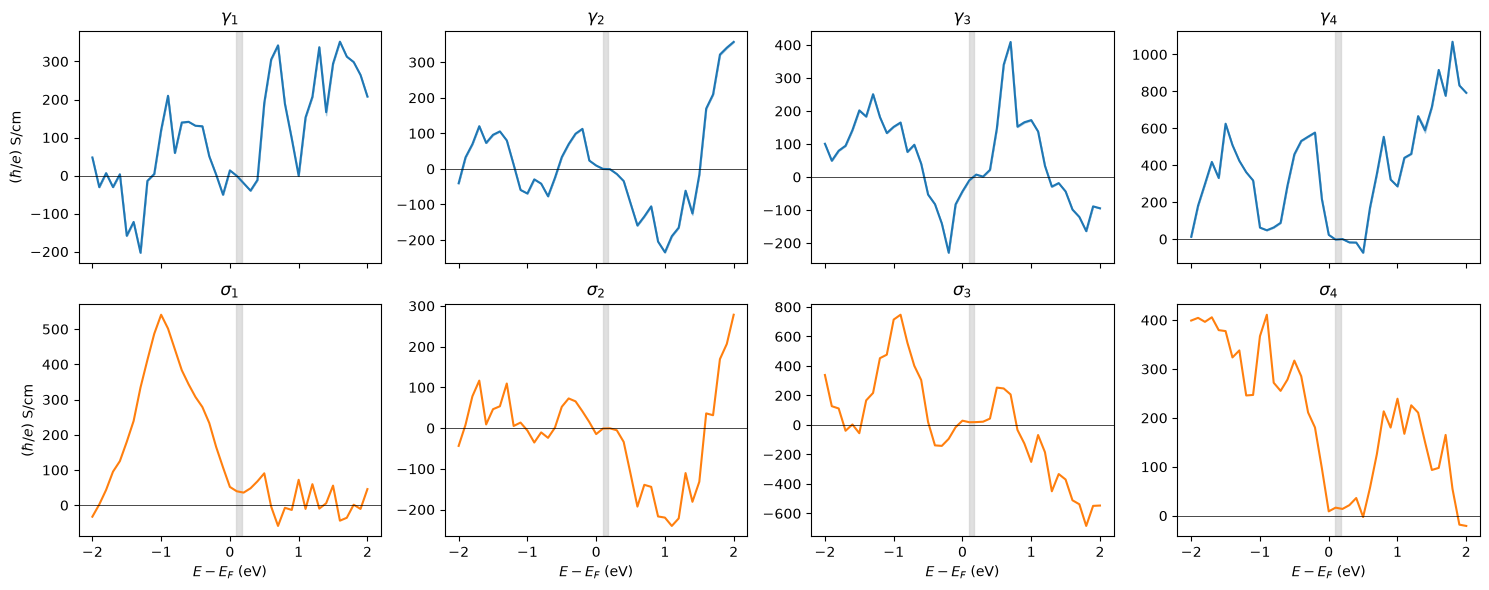

global-sign anchors vs SM25 Fig. 2 (all must match):
  gamma_1(E_F-1.3 eV): negative  (SM25: negative)
  gamma_1(E_F+0.8 eV): positive  (SM25: positive)
  gamma_4 positive fraction: 0.90  (SM25: mostly positive)


In [4]:
sac48 = np.load(W / 'te24_sac_48.npz')
shc = np.load(W / 'te24_shc_scan.npz')
fermis = sac48['fermis']; x = fermis - E_FERMI
to_scm = lambda v: to_si_units(v, 'spin_hall_conductivity', cell_volume_bohr3=V_CELL)

ga, ge = decompose(sac48['gamma'])
sig = shc['sig']

fig, ax = plt.subplots(2, 4, figsize=(15, 6), sharex=True)
for a in range(4):
    ax[0, a].plot(x, to_scm(ga[:, a]), color='C0')
    ax[0, a].fill_between(x, to_scm(ga[:, a] - ge[:, a]), to_scm(ga[:, a] + ge[:, a]),
                          color='C0', alpha=0.3)
    ax[0, a].set_title(rf'$\gamma_{a+1}$')
    ax[1, a].plot(x, sig[:, a], color='C1')
    ax[1, a].set_title(rf'$\sigma_{a+1}$')
    for row in (0, 1):
        ax[row, a].axhline(0, color='k', lw=0.5)
        ax[row, a].axvspan(vbm - E_FERMI, cbm - E_FERMI, color='0.8', alpha=0.6)
    ax[1, a].set_xlabel(r'$E - E_F$ (eV)')
ax[0, 0].set_ylabel(r'$(\hbar/e)$ S/cm'); ax[1, 0].set_ylabel(r'$(\hbar/e)$ S/cm')
plt.tight_layout(); plt.show()

print('global-sign anchors vs SM25 Fig. 2 (all must match):')
for e0, expect in ((-1.3, 'negative'), (0.8, 'positive')):
    i = int(np.abs(x - e0).argmin())
    print(f'  gamma_1(E_F{e0:+.1f} eV): {"negative" if ga[i,0]<0 else "positive"}  (SM25: {expect})')
print(f'  gamma_4 positive fraction: {(ga[:,3]>0).mean():.2f}  (SM25: mostly positive)')

### 4. Symmetry consistency: the $\gamma_2$ story, fully resolved

The original (3,3,4)-mesh 18-WF model showed a $\gamma_2$ relative error of
~16% and an ~8% residual under the bare $C_3$ rotation.  The resolution came
in **two independent pieces**: the dense, properly-windowed model (this
notebook) removed the Fourier-interpolation noise, and the exact-anchor kernel
corrections (see the intro) removed the rest — with both in place every
channel is $D_3$-consistent to $\le$2.3% and the exact-$C_3$ residual drops
to **0.4–0.5%**:

In [5]:
sac24 = np.load(W / 'te24_sac_24.npz')
print(f'{"scan":>14s}   gamma rel err (alpha=1..4)          C3 residual')
for tag, d in (('24^3/50 meV', sac24), ('48^3/20 meV', sac48)):
    av, er = decompose(d['gamma'])
    rel = [float(np.abs(er[:, a]).max() / max(np.abs(av[:, a]).max(), 1e-30)) for a in range(4)]
    imax = int(np.abs(av).sum(axis=1).argmax())
    print(f'{tag:>14s}   {np.round(rel, 3)}   {c3_residual(d["gamma"][imax]):.4f}')
print('(3,3,4) 18-WF model, old formula: rel err ~[0.01, 0.16, 0.01, 0.02], C3 ~0.08')
print('(6,6,8) 24-WF model, pre-correction kernel:  rel err ~[0.00, 0.12, 0.00, 0.01], C3 ~0.02')

          scan   gamma rel err (alpha=1..4)          C3 residual
   24^3/50 meV   [0.006 0.014 0.006 0.018]   0.0053
   48^3/20 meV   [0.023 0.012 0.004 0.012]   0.0040
(3,3,4) 18-WF model, old formula: rel err ~[0.01, 0.16, 0.01, 0.02], C3 ~0.08
(6,6,8) 24-WF model, pre-correction kernel:  rel err ~[0.00, 0.12, 0.00, 0.01], C3 ~0.02


All four channels now sit at the ~1–2% level with the $C_3$ residual at
0.4–0.5% — the earlier "$\gamma_2$ is C2-sensitive" reading was a symptom of
the incomplete kernel, not a property of the channel.  What remains is
ordinary coarse-Wannier-mesh interpolation noise; `sitesym` Wannierization
would push it further down.

### 5. The insulating gap: SAC vanishes, SH conductivity doesn't

SM25's central physical point: the SAC is a genuine Fermi-surface quantity
(the $-f'$ factor in Eq. 1), so it **must vanish inside the gap** — while the
conventional spin Hall conductivity, a Fermi-sea property, stays finite there
(one of the paper's three "critical problems" with the conventional spin
current).

In [6]:
mid = 0.5 * (vbm + cbm) - E_FERMI      # the model gap is only ~80 meV wide
i_gap = int(np.abs(x - mid).argmin())
peak = np.abs(to_scm(ga)).max()
print(f'|gamma_alpha| at the in-gap point (E-E_F = {x[i_gap]:+.2f} eV): '
      f'{np.round(np.abs(to_scm(ga[i_gap])), 2)} (hbar/e) S/cm')
print(f'  -> {np.abs(to_scm(ga[i_gap])).max() / peak * 100:.2f}% of the scan peak '
      f'({peak:.0f}); the residue is the 20 meV smearing tail across the 78 meV gap')
print()
print('TRUE in-gap sigma_alpha (mid-gap), (hbar/e) S/cm:')
for tag in ('48', '96'):
    d = np.load(W / f'te24_ingap_{tag}.npz')
    print(f'  {tag}^3 mesh: {np.round(d["sig"], 1)}')
print('  SM25 (256^3): (-15, -2, -24, -4)')

|gamma_alpha| at the in-gap point (E-E_F = +0.10 eV): [ 0.64  0.09 10.11  2.59] (hbar/e) S/cm
  -> 0.95% of the scan peak (1069); the residue is the 20 meV smearing tail across the 78 meV gap

TRUE in-gap sigma_alpha (mid-gap), (hbar/e) S/cm:
  48^3 mesh: [36.7 -0.8 18.7 14.7]
  96^3 mesh: [31.2 -0.5  5.5 -3.6]
  SM25 (256^3): (-15, -2, -24, -4)


The in-gap $\sigma_\alpha$ is **finite** (the valence-only model's exact zero
was a model artifact, not physics) and of SM25's order of magnitude, but it is
**not converged at these meshes** (48³→96³ still moves $\sigma_3,\sigma_4$ by
>10 S/cm; SM25 used 256³) and the $\sigma_1$ sign disagrees while every
$\gamma$ sign anchor matches.  Since this $\sigma$ machinery is certified
against real postw90 (notebook 8), the residual $\sigma$-sign question most
likely sits in SM25's spin-current convention vs postw90's Qiao form — flagged,
not resolved.

**Takeaway.**  With the manifold frozen whole, the conduction states in the
model, and the exact-anchor-corrected $s^i_{na}$/$m_{n\mathbf k}$ kernel,
`analysis.spin_accumulation` reproduces the structure of SM25 Fig. 2: all four
$D_3$ channels at the 1–2% level, exact-$C_3$ residual 0.4–0.5%, global sign
($e=+|e|$ in Eq. 1) and $(\hbar/e)$ S/cm units anchored against the published
figure, and the SAC's defining Fermi-surface property (vanishing in the gap
where $\sigma$ survives) confirmed.  waw-native, multi-core, no
`wannier90.x`.